In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import skimage.color as color
import scipy.ndimage.interpolation as sni
import caffe

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
! wget http://eecs.berkeley.edu/~rich.zhang/projects/2016_colorization/files/demo_v2/colorization_release_v2.caffemodel -O models/colorization_release_v2.caffemodel

--2016-08-29 03:39:26--  http://eecs.berkeley.edu/~rich.zhang/projects/2016_colorization/files/demo_v2/colorization_release_v2.caffemodel
Resolving eecs.berkeley.edu (eecs.berkeley.edu)... 23.253.180.102
Connecting to eecs.berkeley.edu (eecs.berkeley.edu)|23.253.180.102|:80... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://people.eecs.berkeley.edu/~rich.zhang/projects/2016_colorization/files/demo_v2/colorization_release_v2.caffemodel [following]
--2016-08-29 03:39:26--  https://people.eecs.berkeley.edu/~rich.zhang/projects/2016_colorization/files/demo_v2/colorization_release_v2.caffemodel
Resolving people.eecs.berkeley.edu (people.eecs.berkeley.edu)... 128.32.244.183
Connecting to people.eecs.berkeley.edu (people.eecs.berkeley.edu)|128.32.244.183|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 128946764 (123M)
Saving to: 'models/colorization_release_v2.caffemodel'

100%[======================================>] 128,946,764 4.

In [5]:
! wget https://raw.githubusercontent.com/richzhang/colorization/master/models/colorization_deploy_v2.prototxt -O models/colorization_deploy_v2.prototxt

--2016-08-29 03:41:11--  https://raw.githubusercontent.com/richzhang/colorization/master/models/colorization_deploy_v2.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 151.101.52.133
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|151.101.52.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9945 (9.7K) [text/plain]
Saving to: 'models/colorization_deploy_v2.prototxt'

100%[======================================>] 9,945       --.-K/s   in 0.001s  

2016-08-29 03:41:11 (16.1 MB/s) - 'models/colorization_deploy_v2.prototxt' saved [9945/9945]



In [9]:
!wget https://github.com/richzhang/colorization/blob/master/resources/pts_in_hull.npy?raw=true -O pts_in_hull.npy

--2016-08-29 03:42:27--  https://github.com/richzhang/colorization/blob/master/resources/pts_in_hull.npy?raw=true
Resolving github.com (github.com)... 192.30.253.112
Connecting to github.com (github.com)|192.30.253.112|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/richzhang/colorization/raw/master/resources/pts_in_hull.npy [following]
--2016-08-29 03:42:28--  https://github.com/richzhang/colorization/raw/master/resources/pts_in_hull.npy
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/richzhang/colorization/master/resources/pts_in_hull.npy [following]
--2016-08-29 03:42:28--  https://raw.githubusercontent.com/richzhang/colorization/master/resources/pts_in_hull.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 151.101.52.133
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|151.101.52.133|:443... connected.

In [6]:
# gpu_id = 0
# caffe.set_mode_gpu()
# caffe.set_device(gpu_id)

# Select desired model
net = caffe.Net('models/colorization_deploy_v2.prototxt', 'models/colorization_release_v2.caffemodel', caffe.TEST)
# net = caffe.Net('models/colorization_deploy_v2.prototxt', 'models/colorization_release_v2_norebal.caffemodel', caffe.TEST)
# net = caffe.Net('models/colorization_deploy_v1.prototxt', 'models/colorization_release_v1.caffemodel', caffe.TEST)
# If you are training your own network, you may replace the *.caffemodel path with your trained network.

(H_in,W_in) = net.blobs['data_l'].data.shape[2:] # get input shape
(H_out,W_out) = net.blobs['class8_ab'].data.shape[2:] # get output shape

print 'Input dimensions: (%i,%i)'%(H_in,W_in)
print 'Output dimensions: (%i,%i)'%(H_out,W_out)

Input dimensions: (224,224)
Output dimensions: (56,56)


In [10]:
pts_in_hull = np.load('pts_in_hull.npy') # load cluster centers
net.params['class8_ab'][0].data[:,:,0,0] = pts_in_hull.transpose((1,0)) # populate cluster centers as 1x1 convolution kernel
print 'Annealed-Mean Parameters populated'

Annealed-Mean Parameters populated


--2016-08-29 03:57:09--  https://www.dropbox.com/s/maik4w7w0zt8y3l/car_test4.jpg?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 108.160.172.238
Connecting to www.dropbox.com (www.dropbox.com)|108.160.172.238|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://dl.dropboxusercontent.com/content_link/BHbRhM4aGl1rINc0Ej64bKoLEzfn54aSxNZxiRNisqNB32NNPQjys2fJ908UiUjK/file [following]
--2016-08-29 03:57:09--  https://dl.dropboxusercontent.com/content_link/BHbRhM4aGl1rINc0Ej64bKoLEzfn54aSxNZxiRNisqNB32NNPQjys2fJ908UiUjK/file
Resolving dl.dropboxusercontent.com (dl.dropboxusercontent.com)... 45.58.69.69
Connecting to dl.dropboxusercontent.com (dl.dropboxusercontent.com)|45.58.69.69|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344690 (337K) [image/jpeg]
Saving to: 'test.jpg'

100%[======================================>] 344,690     --.-K/s   in 0.05s   

2016-08-29 03:57:10 (6.18 MB/s) - 'test.jpg' saved [344690/344690]



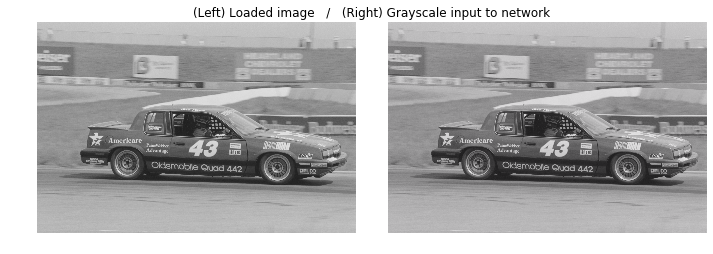

In [26]:
# load the original image
#!wget https://stacks.stanford.edu/image/iiif/qc327dy6074%252F2011-023LUDV-1970-b1_36.0_0019/full/254,168/0/default.jpg -O test.jpg
#!wget https://stacks.stanford.edu/image/iiif/ff322py1299%252F2014-029DELL-BW-1974-b8_27.1_0031/full/255,170/0/default.jpg?download=true -O test.jpg
#!wget "https://photos-5.dropbox.com/t/2/AAB3sxyjuqkQAq8Ery4OcbrXgYFEoYr2dcPPwvHMCvx9Rw/12/2630535/jpeg/32x32/3/1472457600/0/2/car_test.jpg/ELG9ggIY4vXnRiAHKAc/JGiasg2Ta3gcl2V1fHKJq078ZKZ8r3cwgxKKJ8-zaDQ?size_mode=3&dl=0&size=1600x1200" -O test.jpg
#!wget https://www.dropbox.com/s/tbjf88pvzhetwiv/car_test2.jpg?dl=0 -O test.jpg
!wget https://www.dropbox.com/s/maik4w7w0zt8y3l/car_test4.jpg?dl=0 -O test.jpg
img_rgb = caffe.io.load_image('test.jpg')

img_lab = color.rgb2lab(img_rgb) # convert image to lab color space
img_l = img_lab[:,:,0] # pull out L channel
(H_orig,W_orig) = img_rgb.shape[:2] # original image size

# create grayscale version of image (just for displaying)
img_lab_bw = img_lab.copy()
img_lab_bw[:,:,1:] = 0
img_rgb_bw = color.lab2rgb(img_lab_bw)

# resize image to network input size
img_rs = caffe.io.resize_image(img_rgb,(H_in,W_in)) # resize image to network input size
img_lab_rs = color.rgb2lab(img_rs)
img_l_rs = img_lab_rs[:,:,0]

# show original image, along with grayscale input to the network
img_pad = np.ones((H_orig,W_orig/10,3))
plt.imshow(np.hstack((img_rgb, img_pad, img_rgb_bw)))
plt.title('(Left) Loaded image   /   (Right) Grayscale input to network')
plt.axis('off');

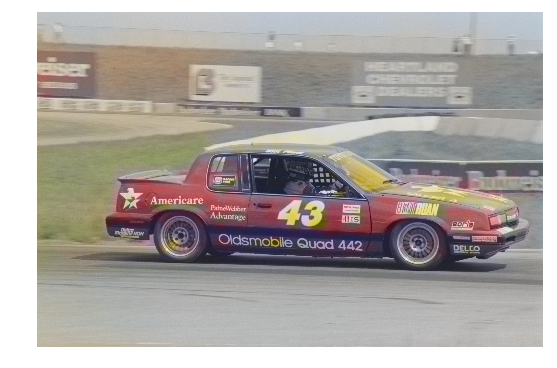

In [27]:
net.blobs['data_l'].data[0,0,:,:] = img_l_rs-50 # subtract 50 for mean-centering
net.forward() # run network

ab_dec = net.blobs['class8_ab'].data[0,:,:,:].transpose((1,2,0)) # this is our result
ab_dec_us = sni.zoom(ab_dec,(1.*H_orig/H_out,1.*W_orig/W_out,1)) # upsample to match size of original image L
img_lab_out = np.concatenate((img_l[:,:,np.newaxis],ab_dec_us),axis=2) # concatenate with original image L
img_rgb_out = np.clip(color.lab2rgb(img_lab_out),0,1) # convert back to rgb

plt.imshow(img_rgb_out);
plt.axis('off');